In [7]:
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import RemoveMessage
from langchain_core.messages import HumanMessage

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenRouter(
    model="openai/gpt-oss-20b:free",
    temperature=0
)

In [4]:
class ChatState(MessagesState):
    summary: str 

In [5]:
def chat_node(state: ChatState):
    messages = []
    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Summary of previous conversation: {state['summary']}"
            })
    messages.extend(state["messages"])
    print(messages)
    response = model.invoke(messages)
    return {"messages": [response]}

In [8]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [9]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [10]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

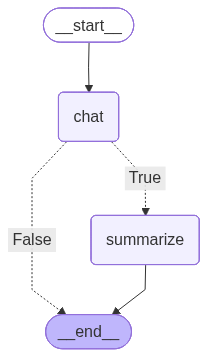

In [11]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [13]:
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [14]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='80991412-3772-4700-81e5-dd07b723df35')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : **Quantum Physics in a Nutshell**

Quantum physics (or quantum mechanics) is the


In [15]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='80991412-3772-4700-81e5-dd07b723df35'), AIMessage(content='**Quantum Physics in a Nutshell**\n\nQuantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other elementary particles. It replaces the deterministic, continuous picture of classical physics with a probabilistic, discrete framework that has been confirmed by countless experiments.\n\n---\n\n## 1. Core Principles\n\n| Principle | What It Means | Key Consequences |\n|-----------|---------------|------------------|\n| **Wave–Particle Duality** | Particles such as electrons exhibit both particle-like and wave-like properties. | Interference patterns in double‑slit experiments; electron diffraction. |\n| **Quantization** | Certain physical quantities (energy, angular momentum, etc.) can only take on discrete values. | Energy levels in 

In [16]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='80991412-3772-4700-81e5-dd07b723df35'), AIMessage(content='**Quantum Physics in a Nutshell**\n\nQuantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other elementary particles. It replaces the deterministic, continuous picture of classical physics with a probabilistic, discrete framework that has been confirmed by countless experiments.\n\n---\n\n## 1. Core Principles\n\n| Principle | What It Means | Key Consequences |\n|-----------|---------------|------------------|\n| **Wave–Particle Duality** | Particles such as electrons exhibit both particle-like and wave-like properties. | Interference patterns in double‑slit experiments; electron diffraction. |\n| **Quantization** | Certain physical quantities (energy, angular momentum, etc.) can only take on discrete values. | Energy levels in 

In [17]:

run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='80991412-3772-4700-81e5-dd07b723df35'), AIMessage(content='**Quantum Physics in a Nutshell**\n\nQuantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, electrons, photons, and other elementary particles. It replaces the deterministic, continuous picture of classical physics with a probabilistic, discrete framework that has been confirmed by countless experiments.\n\n---\n\n## 1. Core Principles\n\n| Principle | What It Means | Key Consequences |\n|-----------|---------------|------------------|\n| **Wave–Particle Duality** | Particles such as electrons exhibit both particle-like and wave-like properties. | Interference patterns in double‑slit experiments; electron diffraction. |\n| **Quantization** | Certain physical quantities (energy, angular momentum, etc.) can only take on discrete values. | Energy levels in 